# Generación de Dataset Sintético para Detección de Objetos
## Sistema de Inventario Automático

Este notebook crea imágenes sintéticas combinando objetos individuales para entrenar YOLOv8.

**Estrategia:**
1. Cargar imágenes individuales de objetos (CPU, Mesa, Mouse, etc.)
2. Crear escenas sintéticas del salón combinando múltiples objetos
3. Generar automáticamente las anotaciones en formato YOLO
4. Crear dataset balanceado para entrenamiento

In [1]:
# Instalación de dependencias necesarias
!pip install ultralytics opencv-python pillow numpy albumentations imgaug 

  Using cached pyyaml-6.0.3-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached pydantic-2.12.4-py3-none-any.whl.metadata (89 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 79.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 49.4 MB/s  0:00:01 eta 0:00:01
Using cached pydantic-2.12.4-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp313-cp313-manylinux_2_17_x86

In [3]:
import numpy as np
import cv2
import os
import random
from pathlib import Path
import shutil
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Configuración

In [4]:
# Rutas
PROCESSED_DIR = "../objetos-salon/processed"
SYNTHETIC_DIR = "./synthetic_dataset"
YOLO_DIR = "./yolo_dataset"

# Clases (sin 'nada' para detección)
CLASSES = ['cpu', 'mesa', 'mouse', 'pantalla', 'silla', 'teclado']
CLASS_TO_ID = {cls: idx for idx, cls in enumerate(CLASSES)}

# Parámetros de generación
NUM_SYNTHETIC_IMAGES = 200  # Número de imágenes sintéticas a generar
IMAGE_SIZE = (640, 640)  # Tamaño para YOLO
MIN_OBJECTS = 3  # Mínimo de objetos por imagen
MAX_OBJECTS = 8  # Máximo de objetos por imagen
OBJECT_SCALE_RANGE = (0.15, 0.35)  # Escala de los objetos (15% a 35% del tamaño de la imagen)

print(f"Configuración:")
print(f"  - Clases a detectar: {len(CLASSES)}")
print(f"  - Imágenes a generar: {NUM_SYNTHETIC_IMAGES}")
print(f"  - Objetos por imagen: {MIN_OBJECTS}-{MAX_OBJECTS}")
print(f"  - Tamaño de imagen: {IMAGE_SIZE}")

Configuración:
  - Clases a detectar: 6
  - Imágenes a generar: 200
  - Objetos por imagen: 3-8
  - Tamaño de imagen: (640, 640)


## Paso 1: Cargar Imágenes de Objetos Individuales

In [5]:
def cargar_objetos_individuales(processed_dir, classes):
    """
    Carga todas las imágenes de objetos individuales organizadas por clase
    """
    objetos = {cls: [] for cls in classes}
    
    for cls in classes:
        clase_dir = os.path.join(processed_dir, cls)
        if not os.path.exists(clase_dir):
            print(f"⚠️ Carpeta no encontrada: {clase_dir}")
            continue
        
        # Buscar imágenes en múltiples formatos
        imagenes = glob.glob(os.path.join(clase_dir, "*.png")) + \
                   glob.glob(os.path.join(clase_dir, "*.jpg")) + \
                   glob.glob(os.path.join(clase_dir, "*.jpeg"))
        
        for img_path in imagenes:
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    objetos[cls].append(img)
            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
        
        print(f"✅ {cls:>10}: {len(objetos[cls])} imágenes cargadas")
    
    return objetos

# Cargar objetos
print("Cargando imágenes de objetos individuales...")
print("="*60)
objetos_db = cargar_objetos_individuales(PROCESSED_DIR, CLASSES)
print("="*60)

# Verificar que hay suficientes objetos
total_objetos = sum(len(imgs) for imgs in objetos_db.values())
print(f"\n📊 Total de imágenes cargadas: {total_objetos}")

Cargando imágenes de objetos individuales...
✅        cpu: 206 imágenes cargadas
✅       mesa: 280 imágenes cargadas
✅      mouse: 263 imágenes cargadas
✅   pantalla: 253 imágenes cargadas
✅      silla: 288 imágenes cargadas
✅    teclado: 260 imágenes cargadas

📊 Total de imágenes cargadas: 1550


## Paso 2: Visualizar Objetos Cargados

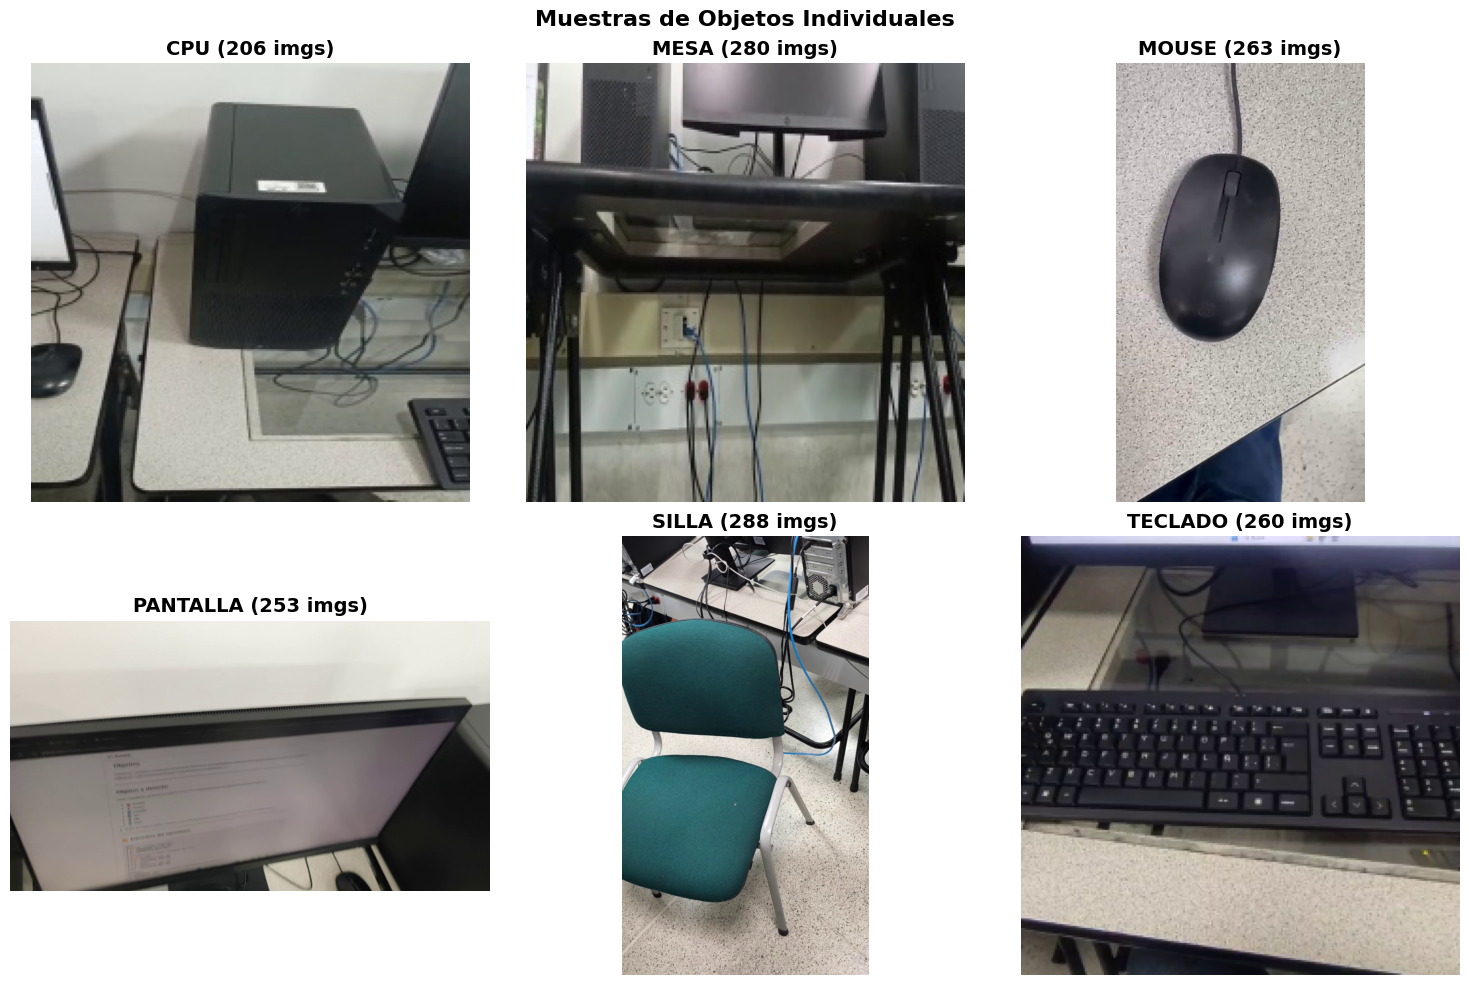

In [6]:
# Visualizar algunas muestras de cada clase
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (cls, imgs) in enumerate(objetos_db.items()):
    if imgs:
        # Seleccionar una imagen aleatoria
        sample_img = random.choice(imgs)
        axes[idx].imshow(sample_img)
        axes[idx].set_title(f"{cls.upper()} ({len(imgs)} imgs)", fontsize=14, weight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'No hay imágenes\nde {cls}', 
                      ha='center', va='center', fontsize=12)
        axes[idx].axis('off')

plt.suptitle('Muestras de Objetos Individuales', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Paso 3: Funciones para Generar Imágenes Sintéticas

In [7]:
def remove_background(img, threshold=240):
    """
    Intenta remover fondo blanco de la imagen
    Devuelve imagen con canal alpha (RGBA)
    """
    # Convertir a escala de grises para detección
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Crear máscara: píxeles oscuros = objeto, píxeles claros = fondo
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY_INV)
    
    # Aplicar operaciones morfológicas para limpiar la máscara
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # Crear imagen RGBA
    rgba = np.dstack([img, mask])
    
    return rgba

def resize_object(img, target_size, scale_range=OBJECT_SCALE_RANGE):
    """
    Redimensiona objeto a un tamaño aleatorio dentro del rango
    """
    img_h, img_w = target_size
    scale = random.uniform(*scale_range)
    
    new_size = int(img_w * scale)
    
    # Mantener relación de aspecto
    h, w = img.shape[:2]
    if h > w:
        new_h = new_size
        new_w = int(w * (new_size / h))
    else:
        new_w = new_size
        new_h = int(h * (new_size / w))
    
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized

def check_overlap(bbox, existing_bboxes, min_distance=20):
    """
    Verifica si un bbox se solapa con otros existentes
    bbox: (x, y, w, h)
    """
    x1, y1, w1, h1 = bbox
    
    for x2, y2, w2, h2 in existing_bboxes:
        # Calcular intersección
        x_overlap = max(0, min(x1 + w1, x2 + w2) - max(x1, x2))
        y_overlap = max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
        
        if x_overlap > 0 and y_overlap > 0:
            return True  # Hay solapamiento
    
    return False

def paste_object_on_background(background, obj_img, position):
    """
    Pega un objeto con transparencia sobre el fondo
    obj_img debe ser RGBA
    """
    x, y = position
    obj_h, obj_w = obj_img.shape[:2]
    
    # Verificar límites
    if x + obj_w > background.shape[1] or y + obj_h > background.shape[0]:
        return background
    
    # Extraer región de interés del fondo
    roi = background[y:y+obj_h, x:x+obj_w]
    
    # Separar RGB y Alpha del objeto
    obj_rgb = obj_img[:, :, :3]
    obj_alpha = obj_img[:, :, 3] / 255.0
    
    # Blending
    for c in range(3):
        roi[:, :, c] = (obj_alpha * obj_rgb[:, :, c] + 
                        (1 - obj_alpha) * roi[:, :, c])
    
    background[y:y+obj_h, x:x+obj_w] = roi
    
    return background

print("✅ Funciones de generación definidas")

✅ Funciones de generación definidas


In [8]:
def generate_synthetic_image(objetos_db, classes, image_size, min_obj=3, max_obj=8):
    """
    Genera una imagen sintética con múltiples objetos y sus anotaciones
    
    Returns:
        image: Imagen sintética (RGB)
        annotations: Lista de (class_id, x_center, y_center, width, height) en formato YOLO normalizado
    """
    img_h, img_w = image_size
    
    # Crear fondo blanco/gris aleatorio (simular pared/mesa)
    bg_color = random.randint(220, 255)
    background = np.ones((img_h, img_w, 3), dtype=np.uint8) * bg_color
    
    # Número aleatorio de objetos
    num_objects = random.randint(min_obj, max_obj)
    
    annotations = []
    placed_bboxes = []
    
    attempts = 0
    max_attempts = num_objects * 10  # Intentos máximos para evitar bucles infinitos
    
    while len(annotations) < num_objects and attempts < max_attempts:
        attempts += 1
        
        # Seleccionar clase aleatoria
        cls = random.choice(classes)
        
        # Verificar que haya imágenes de esta clase
        if not objetos_db[cls]:
            continue
        
        # Seleccionar imagen aleatoria de esa clase
        obj_img = random.choice(objetos_db[cls]).copy()
        
        # Remover fondo blanco
        obj_rgba = remove_background(obj_img)
        
        # Redimensionar objeto
        obj_rgba = resize_object(obj_rgba, image_size)
        
        obj_h, obj_w = obj_rgba.shape[:2]
        
        # Posición aleatoria con margen
        margin = 10
        x = random.randint(margin, max(margin, img_w - obj_w - margin))
        y = random.randint(margin, max(margin, img_h - obj_h - margin))
        
        # Verificar solapamiento
        bbox = (x, y, obj_w, obj_h)
        if check_overlap(bbox, placed_bboxes, min_distance=30):
            continue  # Intenta con otro objeto
        
        # Pegar objeto en el fondo
        background = paste_object_on_background(background, obj_rgba, (x, y))
        
        # Guardar bbox
        placed_bboxes.append(bbox)
        
        # Crear anotación en formato YOLO (normalizado)
        class_id = CLASS_TO_ID[cls]
        x_center = (x + obj_w / 2) / img_w
        y_center = (y + obj_h / 2) / img_h
        width = obj_w / img_w
        height = obj_h / img_h
        
        annotations.append((class_id, x_center, y_center, width, height))
    
    return background, annotations

print("✅ Función de generación de imágenes sintéticas definida")

✅ Función de generación de imágenes sintéticas definida


## Paso 4: Generar Dataset Sintético

In [9]:
# Crear directorios
os.makedirs(SYNTHETIC_DIR, exist_ok=True)
images_dir = os.path.join(SYNTHETIC_DIR, "images")
labels_dir = os.path.join(SYNTHETIC_DIR, "labels")
os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

print(f"Generando {NUM_SYNTHETIC_IMAGES} imágenes sintéticas...")
print("="*60)

for i in tqdm(range(NUM_SYNTHETIC_IMAGES)):
    # Generar imagen y anotaciones
    img, annotations = generate_synthetic_image(
        objetos_db, CLASSES, IMAGE_SIZE, MIN_OBJECTS, MAX_OBJECTS
    )
    
    # Guardar imagen
    img_path = os.path.join(images_dir, f"synthetic_{i:04d}.jpg")
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(img_path, img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
    
    # Guardar anotaciones en formato YOLO
    label_path = os.path.join(labels_dir, f"synthetic_{i:04d}.txt")
    with open(label_path, 'w') as f:
        for ann in annotations:
            class_id, x_center, y_center, width, height = ann
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

print("\n✅ Dataset sintético generado exitosamente!")
print(f"   - Imágenes: {images_dir}")
print(f"   - Etiquetas: {labels_dir}")

Generando 200 imágenes sintéticas...


100%|██████████| 200/200 [00:15<00:00, 13.22it/s]


✅ Dataset sintético generado exitosamente!
   - Imágenes: ./synthetic_dataset/images
   - Etiquetas: ./synthetic_dataset/labels


## Paso 5: Visualizar Imágenes Sintéticas Generadas

/tmp/ipykernel_416981/4176127678.py:74: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/run/media/SoporteOATI/HDD/Maestria/Repositorios/BigData-CNN/.venv/lib64/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


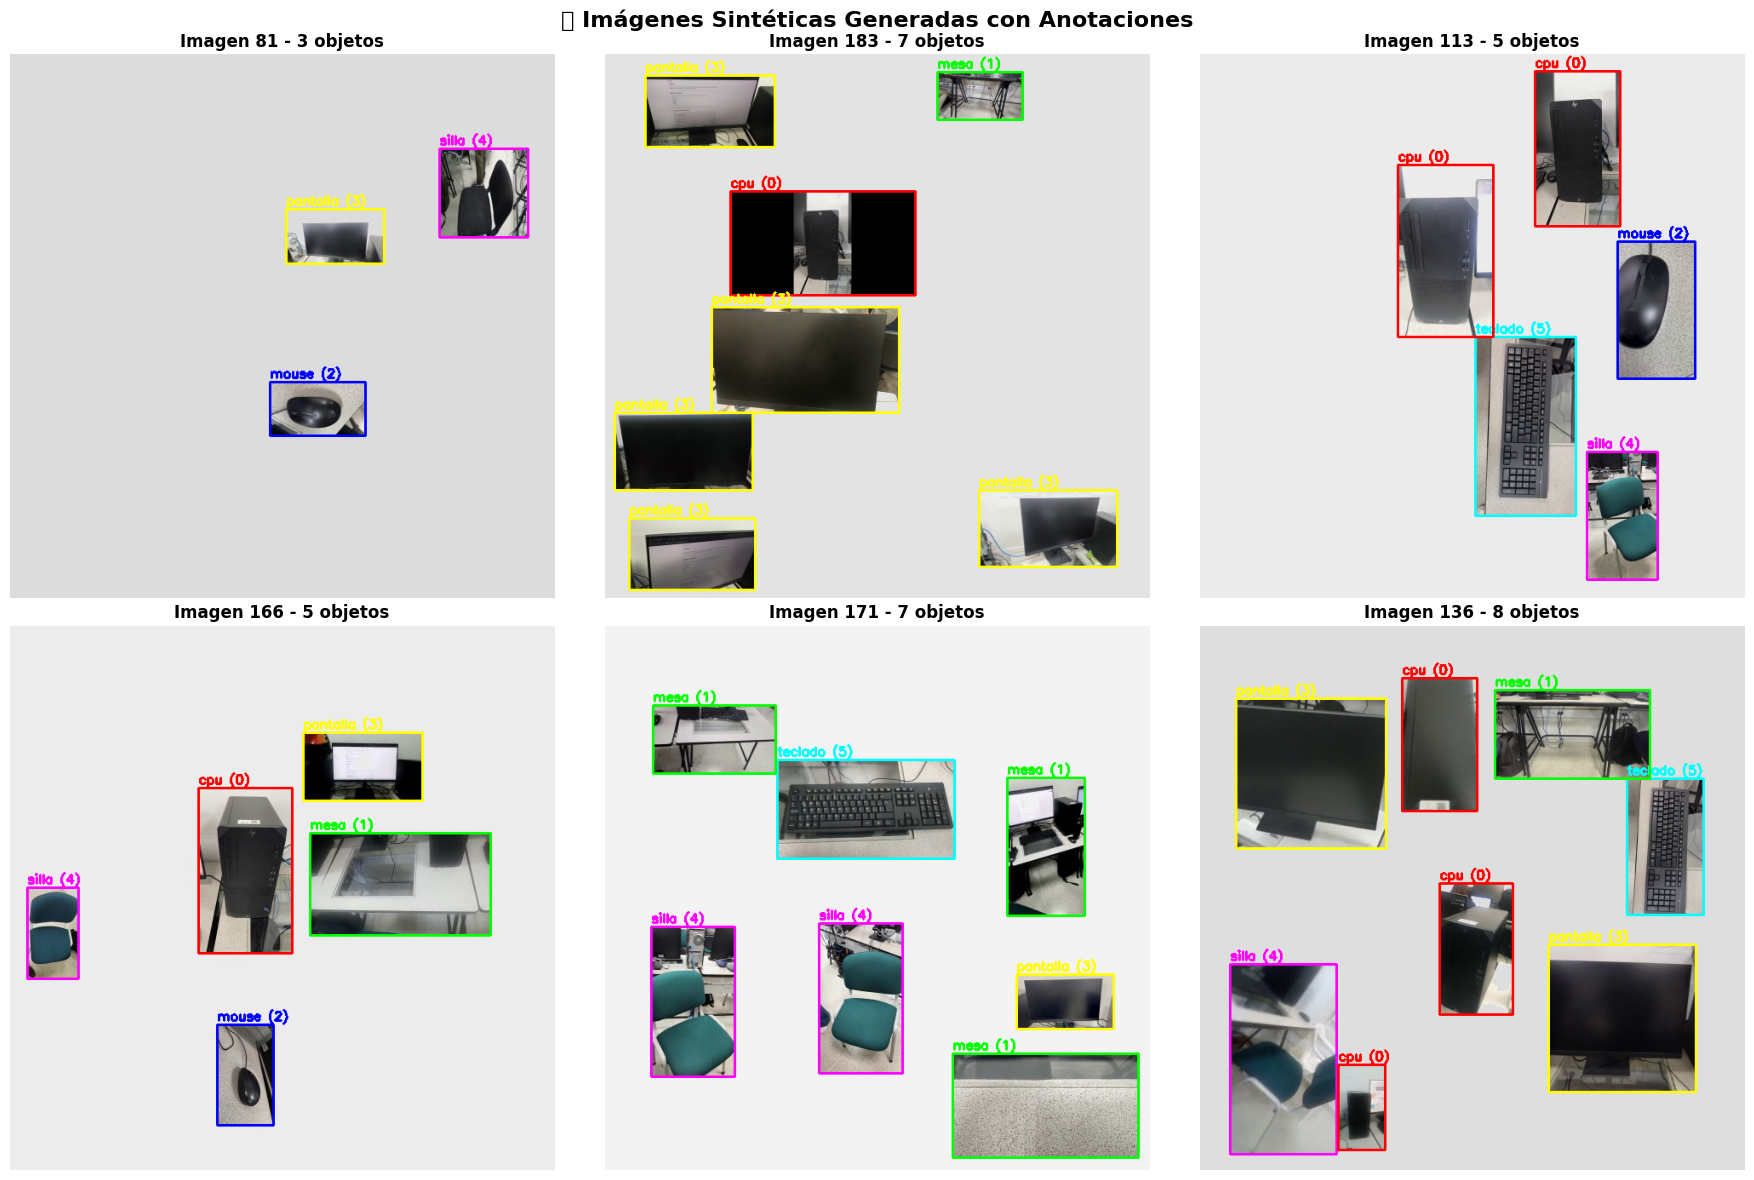

In [10]:
def draw_yolo_boxes(image, label_path, classes):
    """
    Dibuja bounding boxes sobre la imagen según las anotaciones YOLO
    """
    img_h, img_w = image.shape[:2]
    img_display = image.copy()
    
    # Leer anotaciones
    if not os.path.exists(label_path):
        return img_display
    
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    # Colores diferentes para cada clase
    colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255)
    ]
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        
        class_id = int(parts[0])
        x_center = float(parts[1]) * img_w
        y_center = float(parts[2]) * img_h
        width = float(parts[3]) * img_w
        height = float(parts[4]) * img_h
        
        # Calcular esquinas
        x1 = int(x_center - width / 2)
        y1 = int(y_center - height / 2)
        x2 = int(x_center + width / 2)
        y2 = int(y_center + height / 2)
        
        # Dibujar bbox
        color = colors[class_id % len(colors)]
        cv2.rectangle(img_display, (x1, y1), (x2, y2), color, 2)
        
        # Etiqueta
        label = f"{classes[class_id]} ({class_id})"
        cv2.putText(img_display, label, (x1, y1-5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_display

# Visualizar algunas imágenes sintéticas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i in range(6):
    # Cargar imagen aleatoria
    img_idx = random.randint(0, NUM_SYNTHETIC_IMAGES - 1)
    img_path = os.path.join(images_dir, f"synthetic_{img_idx:04d}.jpg")
    label_path = os.path.join(labels_dir, f"synthetic_{img_idx:04d}.txt")
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Dibujar bounding boxes
    img_with_boxes = draw_yolo_boxes(img, label_path, CLASSES)
    
    # Contar objetos
    with open(label_path, 'r') as f:
        num_objects = len(f.readlines())
    
    axes[i].imshow(img_with_boxes)
    axes[i].set_title(f"Imagen {img_idx} - {num_objects} objetos", fontsize=12, weight='bold')
    axes[i].axis('off')

plt.suptitle('🎨 Imágenes Sintéticas Generadas con Anotaciones', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Paso 6: Estadísticas del Dataset

📊 Estadísticas del Dataset Sintético
Total de imágenes generadas: 200
Total de objetos anotados: 1104
Promedio de objetos por imagen: 5.52

Distribución por clase:
         cpu: 182 ( 16.5%)
        mesa: 170 ( 15.4%)
       mouse: 177 ( 16.0%)
    pantalla: 183 ( 16.6%)
       silla: 198 ( 17.9%)
     teclado: 194 ( 17.6%)


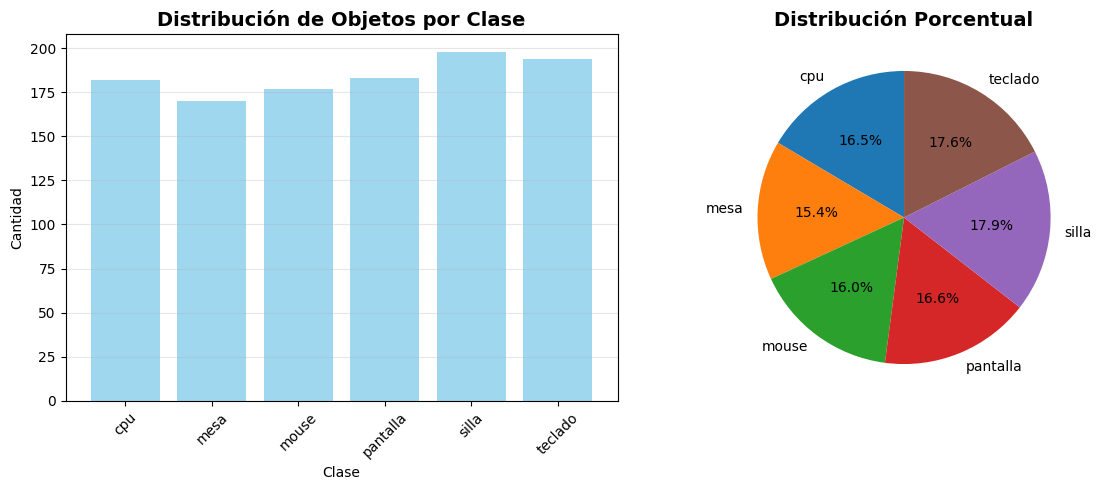

In [11]:
# Contar objetos por clase
class_counts = {cls: 0 for cls in CLASSES}
total_objects = 0

for label_file in os.listdir(labels_dir):
    label_path = os.path.join(labels_dir, label_file)
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id = int(parts[0])
                class_counts[CLASSES[class_id]] += 1
                total_objects += 1

print("📊 Estadísticas del Dataset Sintético")
print("="*60)
print(f"Total de imágenes generadas: {NUM_SYNTHETIC_IMAGES}")
print(f"Total de objetos anotados: {total_objects}")
print(f"Promedio de objetos por imagen: {total_objects/NUM_SYNTHETIC_IMAGES:.2f}")
print("\nDistribución por clase:")
for cls, count in class_counts.items():
    percentage = (count / total_objects) * 100
    print(f"  {cls:>10}: {count:>3} ({percentage:>5.1f}%)")

# Gráfico de distribución
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue', alpha=0.8)
plt.title('Distribución de Objetos por Clase', fontsize=14, weight='bold')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Distribución Porcentual', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

## Paso 7: Crear Estructura para YOLOv8

In [12]:
# Crear estructura de directorios para YOLO
train_images_dir = os.path.join(YOLO_DIR, "train", "images")
train_labels_dir = os.path.join(YOLO_DIR, "train", "labels")
val_images_dir = os.path.join(YOLO_DIR, "val", "images")
val_labels_dir = os.path.join(YOLO_DIR, "val", "labels")

os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)
os.makedirs(val_images_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

# División train/val (80/20)
all_images = sorted(os.listdir(images_dir))
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.8)
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

print(f"División del dataset:")
print(f"  - Entrenamiento: {len(train_images)} imágenes")
print(f"  - Validación: {len(val_images)} imágenes")

# Copiar archivos a train
print("\nCopiando archivos a train...")
for img_name in tqdm(train_images):
    base_name = img_name.replace('.jpg', '')
    
    # Copiar imagen
    src_img = os.path.join(images_dir, img_name)
    dst_img = os.path.join(train_images_dir, img_name)
    shutil.copy2(src_img, dst_img)
    
    # Copiar label
    src_label = os.path.join(labels_dir, base_name + '.txt')
    dst_label = os.path.join(train_labels_dir, base_name + '.txt')
    shutil.copy2(src_label, dst_label)

# Copiar archivos a val
print("Copiando archivos a val...")
for img_name in tqdm(val_images):
    base_name = img_name.replace('.jpg', '')
    
    # Copiar imagen
    src_img = os.path.join(images_dir, img_name)
    dst_img = os.path.join(val_images_dir, img_name)
    shutil.copy2(src_img, dst_img)
    
    # Copiar label
    src_label = os.path.join(labels_dir, base_name + '.txt')
    dst_label = os.path.join(val_labels_dir, base_name + '.txt')
    shutil.copy2(src_label, dst_label)

print("\n✅ Estructura YOLO creada exitosamente!")

División del dataset:
  - Entrenamiento: 160 imágenes
  - Validación: 40 imágenes

Copiando archivos a train...


100%|██████████| 160/160 [00:00<00:00, 14731.07it/s]


Copiando archivos a val...


100%|██████████| 40/40 [00:00<00:00, 14025.43it/s]


✅ Estructura YOLO creada exitosamente!


## Paso 8: Crear archivo de configuración YAML para YOLO

In [13]:
# Crear archivo data.yaml para YOLOv8
yaml_content = f"""# Dataset configuration for YOLOv8
# Sistema de Inventario Automático - Salón de Cómputo

path: {os.path.abspath(YOLO_DIR)}  # dataset root dir
train: train/images  # train images (relative to 'path')
val: val/images  # val images (relative to 'path')

# Classes
nc: {len(CLASSES)}  # number of classes
names: {CLASSES}  # class names
"""

yaml_path = os.path.join(YOLO_DIR, "data.yaml")
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ Archivo data.yaml creado:")
print(yaml_content)
print(f"\n📁 Guardado en: {yaml_path}")

✅ Archivo data.yaml creado:
# Dataset configuration for YOLOv8
# Sistema de Inventario Automático - Salón de Cómputo

path: /run/media/SoporteOATI/HDD/Maestria/Repositorios/BigData-CNN/inventario/yolo_dataset  # dataset root dir
train: train/images  # train images (relative to 'path')
val: val/images  # val images (relative to 'path')

# Classes
nc: 6  # number of classes
names: ['cpu', 'mesa', 'mouse', 'pantalla', 'silla', 'teclado']  # class names


📁 Guardado en: ./yolo_dataset/data.yaml


## ✅ Dataset Sintético Completo

El dataset sintético ha sido generado exitosamente. Ahora puedes:

1. **Continuar con el siguiente notebook** (`02_entrenar_yolov8.ipynb`) para entrenar el modelo
2. **Ajustar parámetros** si deseas generar más imágenes o cambiar la configuración
3. **Agregar datos reales** tomando fotos del salón y mezclándolas con las sintéticas

### Próximos pasos:
- Entrenar YOLOv8 nano
- Exportar a TFLite
- Crear aplicación web